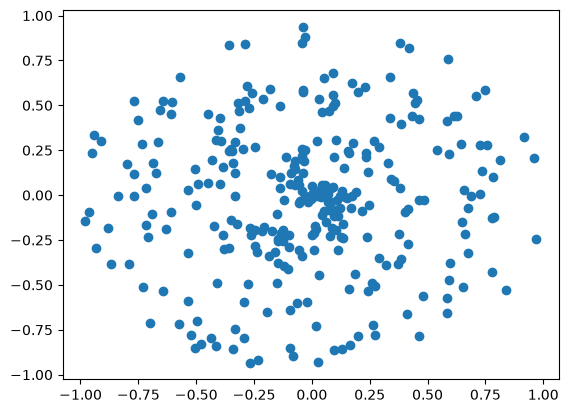

In [1]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X,y = spiral_data(samples = 100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

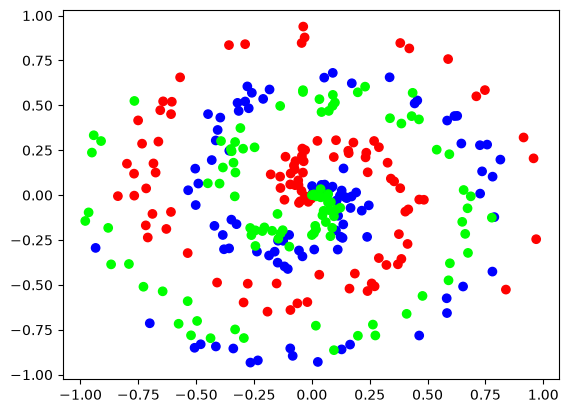

In [2]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="brg")
plt.show()

In [3]:
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):

        self.weights =0.01*np.random.randn(n_inputs,n_neurons) # this is the transposed version of the w matrix remember that...
        self.biases = np.zeros((1,n_neurons))
    def forward(self,inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

X,y = spiral_data(samples=100,classes = 3)

dense1 = Layer_Dense(2,3)
dense1.forward(X)
dense2=Layer_Dense(3,10)
dense2.forward(dense1.output)

# print(dense2.output[:5])


# dense1.output


## Activation functions

### ReLU

In [4]:
import numpy as np
inputs = [0,2,-1,3.3,-2.7,1.1,2.2,-100]
output = np.maximum(0,inputs)

In [5]:
class Activation_ReLU:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs) 

In [6]:
X,y = spiral_data(samples=100,classes=3)
dense1 = Layer_Dense(2,3)
dense1.forward(X)
activation1 = Activation_ReLU()
activation1.forward(dense1.output)

print(activation1.output[:5])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 7.4274081e-05 1.0969164e-04]
 [0.0000000e+00 2.5570381e-04 1.2259498e-04]
 [0.0000000e+00 4.8552279e-04 1.8291285e-05]
 [0.0000000e+00 3.7701402e-04 3.7854823e-04]]


### Softmax activation function

In [7]:
inputs = [[1,2,3,2.5],
     [2,5,-1,2],
     [-1.5,2.7,3.3,-0.8]]
exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
print(probabilities)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


In [55]:
class Activation_Softmax:
    def forward(self,inputs):
        # print(inputs)
        exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
        
        probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
        print(probabilities)
        self.output = probabilities

In [56]:
dense1 = Layer_Dense(2,3)
dense1.forward(X)
ReLU_dense1 =  Activation_ReLU()
ReLU_dense1.forward(dense1.output)

dense2 = Layer_Dense(3,3)
dense2.forward(ReLU_dense1.output)
Softmax_dense2 = Activation_Softmax()
Softmax_dense2.forward(dense2.output)
# print(Softmax_dense2.output[:5])
# np.max([[1,3,2],[4,6,7]],axis=0)

[[0.33333334 0.33333334 0.33333334]
 [0.3211351  0.35462183 0.32424307]
 [0.33333334 0.33333334 0.33333334]
 ...
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]]


## Forward Pass without loss function

### making a forward pass for this neural network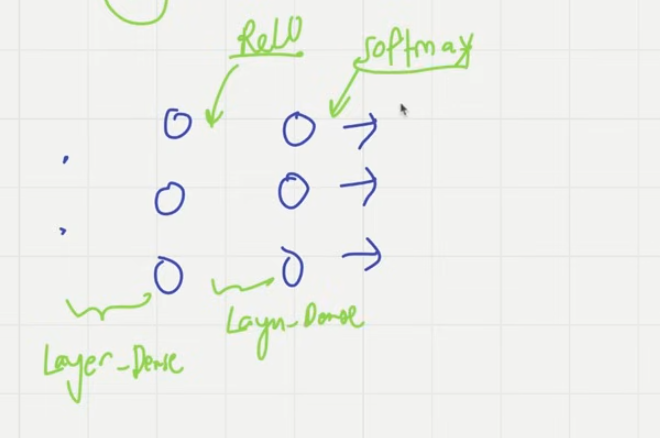

In [10]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

activation2.output

array([[0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.3333335 , 0.33333316],
       [0.33333334, 0.33333433, 0.3333323 ],
       [0.3333333 , 0.3333356 , 0.3333311 ],
       [0.3333334 , 0.33333445, 0.3333321 ],
       [0.3333332 , 0.3333376 , 0.3333292 ],
       [0.3333332 , 0.3333383 , 0.33332855],
       [0.33333355, 0.3333344 , 0.33333212],
       [0.33333355, 0.33333445, 0.333332  ],
       [0.3333333 , 0.33333883, 0.33332786],
       [0.33333293, 0.33334267, 0.3333244 ],
       [0.3333331 , 0.33334216, 0.33332473],
       [0.3333332 , 0.3333419 , 0.3333249 ],
       [0.33333254, 0.3333432 , 0.33332425],
       [0.33333275, 0.33334637, 0.3333209 ],
       [0.3333336 , 0.33333755, 0.3333288 ],
       [0.3333325 , 0.3333476 , 0.3333199 ],
       [0.3333324 , 0.3333472 , 0.33332044],
       [0.3333323 , 0.3333484 , 0.33331928],
       [0.33333218, 0.3333472 , 0.33332068],
       [0.33333218, 0.3333496 , 0.33331826],
       [0.3333325 , 0.3333528 , 0.3333147 ],
       [0.

## Coding loss function

### Cross entropy loss building blocks in python 

In [11]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_target = [0,1,1]
print(softmax_outputs[[0,1,2],class_target])
# print(softmax_outputs[range(len(softmax_outputs)),class_target]) # can also be written like this 

[0.7 0.5 0.9]


In [12]:
print(-np.log(softmax_outputs[range(len(softmax_outputs)),class_target]))
neg_log= -np.log(softmax_outputs[range(len(softmax_outputs)),class_target])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


### Extracting relavent prediction in one hot encoding 

In [13]:
y_true_check = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])
y_pred_clipped_check =np.array([[0.7,0.2,0.1],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
softmax_outputs = (y_true_check*y_pred_clipped_check).sum(axis=1)
neg_log = -np.log(softmax_outputs)
print(np.mean(neg_log))
# softmax_outputs

0.38506088005216804


### Implementing loss class and Implementing Categorical Cross Entropy class

In [14]:
class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss=np.mean(sample_losses)
        return data_loss

In [41]:
class Loss_CategoricalCrossEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples) , y_true]
        elif len(y_true.shape) == 2:
   
            correct_confidences = np.sum(y_pred_clipped*y_true,axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
            

In [42]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_targets = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])

loss_function = Loss_CategoricalCrossEntropy()
loss = loss_function.calculate(softmax_outputs,class_targets)
print(loss)

hello
0.38506088005216804


In [17]:
X,y = spiral_data(samples = 100,classes=3)
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalCrossEntropy()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

loss = loss_function.calculate(activation2.output,y)
print("loss:",loss)

predictions = np.argmax(activation2.output,axis=1)
if len(y.shape) == 2:
    y = np.argmax(y,axis=1)
accuracy =np.mean(predictions == y)
accuracy


loss: 1.0986203


np.float64(0.3233333333333333)

In [18]:
softmax_outputs = np.array([[0.7,0.2,0.1],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_targets = np.array([0,1,1])

predictions = np.argmax(softmax_outputs,axis=1)

if len(class_targets.shape) == 2:
    class_targets = np.argmax(class_targets , axis=1)

accuracy=np.mean(predictions == class_targets)
accuracy

np.float64(1.0)

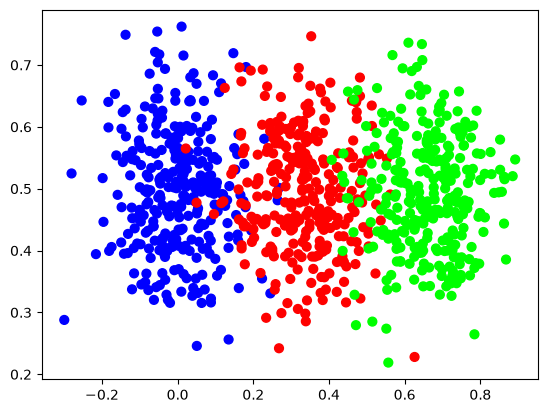

In [19]:
from nnfs.datasets import vertical_data
X,y = vertical_data(samples=300,classes=3)
plt.scatter(X[:,0],X[:,1],c=y,s=40,cmap="brg")

In [20]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalEntropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights = 0.05 * np.random.randn(2,3)
    dense1.biases= 0.05 * np.random.randn(1,3)
    dense2.weights = 0.05 * np.random.randn(3,3)
    dense2.biases = 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output,y)

    predictions = np.argmax(activation2.output,axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New set of weights found, iteration:",iteration,"loss:",loss,"acc:",accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss

NameError: name 'Loss_CategoricalEntropy' is not defined

In [ ]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalEntropy()

lowest_loss = 9999999
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
    dense1.weights += 0.05 * np.random.randn(2,3)
    dense1.biases += 0.05 * np.random.randn(1,3)
    dense2.weights += 0.05 * np.random.randn(3,3)
    dense2.biases += 0.05 * np.random.randn(1,3)

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    loss = loss_function.calculate(activation2.output,y)

    predictions = np.argmax(activation2.output,axis=1)
    accuracy = np.mean(predictions == y)

    if loss < lowest_loss:
        print("New set of weights found, iteration:",iteration,"loss:",loss,"acc:",accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    else:
        dense1.weights=best_dense1_weights.copy()
        dense1.biases =best_dense1_biases.copy()
        dense2.weights=best_dense2_weights.copy()
        dense2.biases=best_dense2_biases.copy()

##  Backpropagation from scratch on a single neuron

In [ ]:
np.where(10>0,1.0,0.0)

In [ ]:
# doing for a single neuron(perceptron)

weights = np.array([-3.0,-1.0,2.0])
bias = 1.0
inputs = np.array([1.0,-2.0,3.0])
target_output = 0.0
learning_rate = 0.001

def relu(x):
    return np.maximum(x,0)
def relu_derivative(x):
    return np.where(x > 0,1.0,0.0)


for iteration in range(200):
    # forward pass
    linear_output = np.dot(inputs,weights.T)+bias
    output = relu(linear_output) 
    loss = (output - target_output) ** 2
    # backward pass
    dloss_drelu = 2 * (output - target_output)
    drelu_dsum = relu_derivative(output)
    dsum_dmul = 1
    dmul_dW = inputs
    dmul_db = bias
    

    gradient_vector = dloss_drelu * drelu_dsum * dsum_dmul * dmul_dW
    bias_gradient = dloss_drelu * drelu_dsum * dsum_dmul * dmul_db
    
    weights = weights - learning_rate * gradient_vector
    bias = bias - learning_rate*bias_gradient
    print("iteation:",iteration+1,"| loss:",loss)

print("obtimized weights:",weights)
print("bias:",bias)
    

## Back propagation on layer of neurons 

In [ ]:
inputs = np.array([1.0,2.0,3.0,4.0])
weights = np.array([[0.1,0.2,0.3,0.4],
                   [0.5,0.6,0.7,0.8],
                   [0.9,1.0,1.1,1.2]])
biases = np.array([0.1,0.2,0.3])

def relu(x):
    return np.maximum(x,0)
def relu_derivative(x):
    return np.where(x > 0,1.0,0.0)
target_output = 0.0
learning_rate = 0.001


for iteration in range(100):
    # forwar pass
    Z = np.dot(inputs,weights.T)+biases # we got z1,z2,z3
    A = relu(Z)
    y = np.sum(A)
    loss = y**2

    # backward pass 
    dloss_dy = 2*y
    dy_dA = 1
    dloss_dA = dloss_dy * dy_dA
    dA_dZ = relu_derivative(Z)
    dloss_dZ = dloss_dA*dA_dZ
    #print(dloss_dZ)
   

    dloss_dW = np.outer(dloss_dZ,inputs)
    # print(dloss_dW)
    # print(dloss_dZ)
    # print(inputs)
    dloss_db = dloss_dZ

    weights = weights - learning_rate * dloss_dW
    biases = biases - learning_rate * dloss_db
    print("iteation:",iteration+1,"| loss:",loss)

print("\nobtimized weights:",weights)
print("bias:",biases)



## Coding layered back propagation

### For weights

In [21]:
dvalues = np.array([[1.,1.,1.],[2.,2.,2.],[3.,3.,3.]])
inputs = np.array([[1,2,3,2.5],
                   [2.,5.,-1.,2],
                   [-1.5,2.7,3.3,-0.8]])

dweights = np.dot(inputs.T,dvalues)
dweights

array([[ 0.5,  0.5,  0.5],
       [20.1, 20.1, 20.1],
       [10.9, 10.9, 10.9],
       [ 4.1,  4.1,  4.1]], dtype=float32)

### For biases

In [22]:
biases = np.array([[2,3,0.5]])

dbiases = np.sum(dvalues,axis = 0,keepdims =True)
dbiases

array([[6., 6., 6.]])

### For inputs

In [23]:
dvalues = np.array([[1.,1.,1.],[2.,2.,2.],[3.,3.,3.]])


weights = np.array([[0.2,0.8,-0.5,1],
                    [0.5,-0.91,0.26,-0.5],
                    [-0.26,-0.27,0.17,0.87]]).T # recall that our weights are stored in transposed form

dinputs = np.dot(dvalues,weights.T)
dinputs

array([[ 0.44, -0.38, -0.07,  1.37],
       [ 0.88, -0.76, -0.14,  2.74],
       [ 1.32, -1.14, -0.21,  4.11]], dtype=float32)

### Class implementation

In [24]:
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):

        self.weights =0.01*np.random.randn(n_inputs,n_neurons) # this is the transposed version of the w matrix remember that...
        self.biases = np.zeros((1,n_neurons))
    def forward(self,inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

    # backward pass
    def backward(self,inputs,dvalues):
        self.dweights = np.dot(inputs.T,dvalues)
        self.dbiases = np.sum(dvalues,axis=0,keepdims = True)
        self.dinputs = np.sum(dvalues,self.weights.T)
    

In [25]:
class Activation_ReLU:
    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.maximum(0,inputs) 

    def backward(self,dvalues):
        self.dinputs = dvalues

        self.dinputs[self.inputs <=0] = 0
    

In [26]:
class Loss_CategoricalCrossEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples) , y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped*y_true,axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    def backward(self,dvalues,y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true/dvalues
        self.dinputs = self.dinputs / samples

## Combines Softmax activation and cross entropy loss for faster backpropagation 

In [62]:
class Activation_Softmax_Loss_CategoricalCrossEntropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossEntropy()

    def forward(self,inputs,y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output,y_true)
        
    def backward(self,dvalues,y_true):
        samples = len(dvalues)

        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true,axis = 1)
        self.dinputs = dvalues.copy() # just for safety measures 

        self.dinputs[range(samples),y_true] -= 1

        self.dinputs /= samples # normalization 
    

In [65]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_targets = np.array([0,1,1])

softmax_loss = Activation_Softmax_Loss_CategoricalCrossEntropy()
softmax_loss.backward(softmax_outputs,class_targets)

dvalues1 = softmax_loss.dinputs
print(dvalues1)


[[-0.1         0.03333333  0.06666667]
 [ 0.03333333 -0.16666667  0.13333333]
 [ 0.00666667 -0.03333333  0.02666667]]


# Coding the entire neural network forward backward pass in Python

In [31]:
class Layer_Dense:
    # initialize values randomly
    def __init__(self,n_inputs,n_neurons):
        self.weights = np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros((1,n_neurons))

    # forward pass 
    def forward(self,inputs):
        self.inputs=inputs # save inputs
        
        self.output = np.dot(self.inputs,self.weights)
    def backward(self,dvalues):
        self.dweights = np.dot(self.inputs.T,dvalues)
        self.dbiases = np.sum(dvalues,axis = 0,keepdims = True)
        self.dinputs = np.dot(dvalues,self.weights.T)
        

In [32]:
class Acivation_ReLU:
    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.maximum(0,self.inputs)

    def backward(self,dvalues):
        
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

    
                    

In [57]:
class Activation_Softmax:
    def forward(self,inputs):
        exponents= np.exp(inputs-np.max(inputs,axis = 1,keepdims = True))
        probabilities = exponents/np.sum(exponents,axis=1,keepdims=True)
        self.output = probabilities
        
        

In [59]:
class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss=np.mean(sample_losses)
        return data_loss
        
class Loss_CategoricalCrossEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples) , y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped*y_true,axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    def backward(self,dvalues,y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true/dvalues
        self.dinputs = self.dinputs / samples # for normalization so that values wont get too far 



In [67]:
class Activation_Softmax_Loss_CategoricalCrossEntropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossEntropy()

    def forward(self,inputs,y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output,y_true)
        
    def backward(self,dvalues,y_true):
        samples = len(dvalues)

        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true,axis = 1)
        self.dinputs = dvalues.copy() # just for safety measures 

        self.dinputs[range(samples),y_true] -= 1

        self.dinputs /= samples # normalization 

In [72]:
X,y = spiral_data(samples = 100,classes=3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossEntropy()


# Forward pass
dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
loss = loss_activation.forward(dense2.output,y)

print(loss_activation.output[:5])
# Print loss value
print('loss:', loss)


predictions = np.argmax(loss_activation.output,axis = 1 )
if len(y.shape) == 2:
    y = np.argmax(y,axis = 1)
accuracy = np.mean(y == predictions)

print("acc:",accuracy)

# backward pass
loss_activation.backward(loss_activation.output,y)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

print(dense1.dweights)
print(dense1.dbiases)
print(dense2.dweights)
print(dense2.dbiases)

[[0.33333334 0.33333334 0.33333334]
 [0.33493918 0.33173248 0.33332837]
 [0.3365526  0.32625902 0.33718833]
 [0.33610758 0.32730478 0.33658767]
 [0.33784366 0.32699734 0.33515894]]
loss: 1.1337351
acc: 0.32666666666666666
[[-0.00159652  0.00536144  0.04725698]
 [ 0.01579286 -0.0027339   0.00429192]]
[[0.03402927 0.00489807 0.04582348]]
[[ 0.0234599  -0.03803692  0.01457702]
 [ 0.01005342 -0.02975081  0.0196974 ]
 [ 0.01170076 -0.03204034  0.02033958]]
[[ 0.06324754 -0.08882805  0.02558023]]


## Gradient Descent in nerual network

In [75]:
class Optimizer_SGD:
    def __init__(self,learning_rate=1):
        self.learning_rate=learning_rate

    def update_params(self,layer):
        layer.weights += -self.learning_rate * layer.dweights
        layer.biases += -self.learning_rate * layer.dbiases

In [80]:
X,y = spiral_data(samples = 100,classes=3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossEntropy()

optimizer = Optimizer_SGD(0.001)
for epoc in range(1,10001):

    # Forward pass
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss = loss_activation.forward(dense2.output,y)


    print("epoch: ",epoc,end=", ")

    # Print loss value
    print('loss:', loss,end=", ")
 
    predictions = np.argmax(loss_activation.output,axis = 1 )
    if len(y.shape) == 2:
        y = np.argmax(y,axis = 1)
    accuracy = np.mean(y == predictions)
    
    print("acc:",accuracy)
    
    # backward pass
    loss_activation.backward(loss_activation.output,y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    
    

epoch:  1, loss: 1.1057769, acc: 0.36333333333333334
epoch:  2, loss: 1.1057733, acc: 0.36333333333333334
epoch:  3, loss: 1.1057696, acc: 0.36333333333333334
epoch:  4, loss: 1.105766, acc: 0.36333333333333334
epoch:  5, loss: 1.1057625, acc: 0.36333333333333334
epoch:  6, loss: 1.1057589, acc: 0.36333333333333334
epoch:  7, loss: 1.1057553, acc: 0.36333333333333334
epoch:  8, loss: 1.1057518, acc: 0.36333333333333334
epoch:  9, loss: 1.105748, acc: 0.36333333333333334
epoch:  10, loss: 1.1057445, acc: 0.36333333333333334
epoch:  11, loss: 1.105741, acc: 0.36333333333333334
epoch:  12, loss: 1.1057373, acc: 0.36333333333333334
epoch:  13, loss: 1.1057338, acc: 0.36333333333333334
epoch:  14, loss: 1.1057302, acc: 0.36333333333333334
epoch:  15, loss: 1.1057265, acc: 0.36333333333333334
epoch:  16, loss: 1.1057229, acc: 0.36333333333333334
epoch:  17, loss: 1.1057194, acc: 0.36333333333333334
epoch:  18, loss: 1.1057158, acc: 0.36333333333333334
epoch:  19, loss: 1.1057123, acc: 0.3633